**Introduction**

This project analyzes IMF (International Monetary Fund) international trade statistics for 192 countries over the last 10 years (2016–2025), covering both the dollar value of goods traded and price/volume index scores that track how trade costs shift over time.

The raw data arrives in a "wide" format — over 1,300 columns, one per year/period, plus 40+ metadata columns per series. Before analysis, this needed reshaping, cleaning, and validating: fixing inconsistent currency reporting, normalizing values reported at different scales (Units vs Millions vs Billions), and removing data entry errors from the original source. The result is a clean dataset used to identify top trading countries and examine trade trends across the last decade, including the COVID-19 disruption.

The objective is end-to-end exploratory data analysis: clean the raw data, derive meaningful features, visualize patterns, and draw evidence-based insights about global trade.

**Attribute Dictionary**

The table below documents every column in the final cleaned dataset,
including the data type and what each column represents.

In [51]:
# An Attribute Dictionary from the actual dataset ──
descriptions = {
    'COUNTRY': 'Reporting country',
    'INDICATOR': 'Trade measure type (Exports/Imports of goods, Price deflator, Volume index, Price index)',
    'TRADE_FLOW': 'Export or Import',
    'VALUATION': 'Customs basis - FOB (exports) or CIF (imports)',
    'SCALE': 'Original reporting magnitude (Units/Thousands/Millions/Billions)',
    'CURRENCY': 'USD, Domestic, or Not Applicable',
    'VALUE': 'The measurement - USD amount or index score',
    'YEAR': 'Calendar year',
    'IS_EXPORT': 'Derived - True if export, False if import',
    'VALUE_CATEGORY': 'Derived - Low/Medium/High grouping',
    'TREND': 'Derived - Increasing/Decreasing/No Data vs previous year'
}

attribute_dict = pd.DataFrame({
    'Column': final.columns,
    'Data Type': final.dtypes.astype(str).values,
    'Description': [descriptions.get(c, '') for c in final.columns]
})

attribute_dict

,Column,Data Type,Description
0,COUNTRY,object,Reporting country
1,INDICATOR,object,"Trade measure type (Exports/Imports of goods, ..."
2,TRADE_FLOW,object,Export or Import
3,VALUATION,object,Customs basis - FOB (exports) or CIF (imports)
4,SCALE,object,Original reporting magnitude (Units/Thousands/...
5,CURRENCY,object,"USD, Domestic, or Not Applicable"
6,VALUE,float64,The measurement - USD amount or index score
7,YEAR,int64,Calendar year
8,IS_EXPORT,bool,"Derived - True if export, False if import"
9,VALUE_CATEGORY,object,Derived - Low/Medium/High grouping


**Derived Tables**

Two additional tables were created from the cleaned dataset, splitting
dollar trade totals from index scores so they're never mixed together
in the same chart.

In [52]:
# Derived Tables Summary

table_descriptions = {
    'final': 'Full cleaned dataset - all indicator types combined',
    'value_data': 'Subset where CURRENCY = USD - real dollar trade totals, for country comparisons',
    'index_data': 'Subset where CURRENCY = Not Applicable - price/volume index scores, for trend analysis'
}

derived_tables = pd.DataFrame({
    'Table': ['final', 'value_data', 'index_data'],
    'Rows': [final.shape[0], value_data.shape[0], index_data.shape[0]],
    'Columns': [final.shape[1], value_data.shape[1], index_data.shape[1]],
    'Description': [table_descriptions['final'], table_descriptions['value_data'], table_descriptions['index_data']]
})

derived_tables

,Table,Rows,Columns,Description
0,final,6014,11,Full cleaned dataset - all indicator types com...
1,value_data,3751,11,Subset where CURRENCY = USD - real dollar trad...
2,index_data,2263,11,Subset where CURRENCY = Not Applicable - price...


**Data Source**

International Monetary Fund (IMF), International Trade in Goods statistics — originally published in wide format with one series per row and one column per time period, covering countries worldwide from 1948 through 2026.

**1. Load the data**

In [53]:
import pandas as pd

df = pd.read_csv('Uncleaned_Dataset_FinalProject.csv', low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (5490, 1385)


,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,TYPE_OF_TRANSFORMATION,FREQUENCY,SCALE,DECIMALS_DISPLAYED,TR_DIRECTION,...,2026-M05,2026-M06,2026-Q3,2026-M07,2026-M08,2026-M09,2026-Q4,2026-M10,2026-M11,2026-M12
0,IMF.STA:ITG(4.0.0),SLB.XG_PD.FOB_IX.Q,OBS_VALUE,Solomon Islands,"Exports of goods, Price deflator","Free on board (FOB), Index",Quarterly,Units,NaN,Exports,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IMF.STA:ITG(4.0.0),PHL.XG_PD.FOB_IX.Q,OBS_VALUE,Philippines,"Exports of goods, Price deflator","Free on board (FOB), Index",Quarterly,Units,NaN,Exports,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IMF.STA:ITG(4.0.0),COL.MPI.CIF_IX.Q,OBS_VALUE,Colombia,Import price index,"Cost insurance freight (CIF), Index",Quarterly,Units,NaN,Imports,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IMF.STA:ITG(4.0.0),JPN.XG_PD.FOB_IX.Q,OBS_VALUE,Japan,"Exports of goods, Price deflator","Free on board (FOB), Index",Quarterly,Units,NaN,Exports,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IMF.STA:ITG(4.0.0),IRN.MPI.CIF_IX.Q,OBS_VALUE,"Iran, Islamic Republic of",Import price index,"Cost insurance freight (CIF), Index",Quarterly,Units,NaN,Imports,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**2. Data Cleaning**

**Step 1: Remove empty columns**

Columns with nothing in them, or the same value in every row.

In [54]:
useless_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=useless_cols)
print("Removed", len(useless_cols), "columns. New shape:", df.shape)

Removed 152 columns. New shape: (5490, 1233)


**Step 2: Find the year columns**
Checks if a column name starts with 4 digits.

In [55]:
def is_year_column(col_name):
    col_name = str(col_name)
    return col_name[:4].isdigit()

id_cols = [c for c in df.columns if not is_year_column(c)]
year_cols = [c for c in df.columns if is_year_column(c)]
print("Normal columns:", len(id_cols))
print("Year columns:", len(year_cols))

Normal columns: 14
Year columns: 1219


**Step 3: Reshape the data**

Turns "one column per year" into one YEAR column and one VALUE column.

In [56]:
long_df = df.melt(id_vars=id_cols, value_vars=year_cols, var_name='PERIOD', value_name='VALUE')
print("Shape:", long_df.shape)

Shape: (6692310, 16)


**Step 4: Remove missing values**

A blank VALUE means that country didn't report data for that year.

In [57]:
long_df = long_df.dropna(subset=['VALUE'])
print("Shape:", long_df.shape)

Shape: (470269, 16)


**Step 5: Fix data types, keep last 10 years**

1. Extract year from period
2. Converted values to proper numbers
3. Kept only recent data (2016 onwards)

In [58]:
long_df['YEAR'] = long_df['PERIOD'].str[:4].astype(int)
long_df['VALUE'] = pd.to_numeric(long_df['VALUE'], errors='coerce')
long_df = long_df[long_df['YEAR'] >= 2016]
print("Shape:", long_df.shape)

Shape: (140704, 17)


**Step 6: Remove duplicate rows**

In [59]:
before = long_df.shape[0]
long_df = long_df.drop_duplicates()
print("Removed", before - long_df.shape[0], "duplicates")

Removed 0 duplicates


**Step 7: Recover currency info**
Pulls "US Dollar vs local currency" out of a messy text column.

1. Added new column for currency
2. Detect Real USD value
3. Mark Domestic currency

In [60]:
long_df['CURRENCY'] = 'Not Applicable'

is_real_usd = long_df['TYPE_OF_TRANSFORMATION'].str.contains('US dollar', na=False) & \
              ~long_df['TYPE_OF_TRANSFORMATION'].str.contains('index', na=False, case=False)
long_df.loc[is_real_usd, 'CURRENCY'] = 'USD'
long_df.loc[long_df['TYPE_OF_TRANSFORMATION'].str.contains('Domestic currency', na=False), 'CURRENCY'] = 'Domestic'

print(long_df['CURRENCY'].value_counts())

cols_to_drop = ['SERIES_CODE', 'TR_DIRECTION', 'TOPIC', 'INDEX_TYPE',
                'TYPE_OF_TRANSFORMATION', 'SERIES_NAME', 'REFERENCE_PERIOD']
long_df = long_df.drop(columns=cols_to_drop)

long_df = long_df[['COUNTRY', 'INDICATOR', 'TRADE_FLOW', 'FREQUENCY', 'VALUATION',
                    'SCALE', 'TRANSFORMATION', 'CURRENCY', 'PERIOD', 'VALUE', 'YEAR']]
print("Shape:", long_df.shape)

CURRENCY
Not Applicable    93196
USD               39384
Domestic           8124
Name: count, dtype: int64
Shape: (140704, 11)


**Step 8: Keep only comparable data**

1. Annual only, plain values only, US Dollars only.

2. Takes only the rows that meet two conditions:
TRANSFORMATION is empty (NaN) → meaning no special transformation (raw data), 
FREQUENCY is Annual (only yearly data, not quarterly or monthly)

In [61]:
final = long_df[
    (long_df['TRANSFORMATION'].isna()) &
    (long_df['FREQUENCY'] == 'Annual')
].copy()
final = final.drop(columns=['TRANSFORMATION', 'FREQUENCY', 'PERIOD']).reset_index(drop=True)

final = final[(final['CURRENCY'] == 'USD') | (final['CURRENCY'] == 'Not Applicable')].copy()
print("Shape:", final.shape)

Shape: (6142, 8)


**Step 8b: Fix the scale**

1. Converts Units/Thousands/Millions/Billions into one true value.
2. Adjusted the VALUE column so that all numbers are in the same unit (actual USD value).

In [62]:
scale_multiplier = {'Units': 1, 'Thousands': 1_000, 'Millions': 1_000_000, 'Billions': 1_000_000_000}
final['VALUE_MULTIPLIER'] = final['SCALE'].map(scale_multiplier)

final.loc[final['CURRENCY'] == 'USD', 'VALUE'] = final['VALUE'] * final['VALUE_MULTIPLIER']
final = final.drop(columns=['VALUE_MULTIPLIER'])

print(final[final['CURRENCY']=='USD'][['COUNTRY','VALUE']].head())

              COUNTRY         VALUE
0            Pakistan  4.679864e+10
1  West Bank and Gaza  9.264990e+08
2            Pakistan  2.035519e+10
3  West Bank and Gaza  5.363768e+09
4             Hungary  2.593123e+13


**Step 8c: Remove impossible values**

1. Two rows had a data entry error from the original source.

2. Removes rows where VALUE is extremely large
1e13 means 10,000,000,000,000 (10 trillion).

In [63]:
before = final.shape[0]
final = final[final['VALUE'] < 1e13].copy()
print("Removed", before - final.shape[0], "impossible rows")

Removed 7 impossible rows


**Step 9: Fill missing TRADE_FLOW**

Uses the INDICATOR column to fill in Export/Import, then re-checks duplicates.


In [64]:
final.loc[final['TRADE_FLOW'].isna() & final['INDICATOR'].str.contains('Export'), 'TRADE_FLOW'] = 'Exports of goods'
final.loc[final['TRADE_FLOW'].isna() & final['INDICATOR'].str.contains('Import'), 'TRADE_FLOW'] = 'Imports of goods'

before = final.shape[0]
final = final.drop_duplicates()
print("Removed", before - final.shape[0], "duplicates. Shape:", final.shape)

Removed 117 duplicates. Shape: (6018, 8)


**Step 10: Add IS_EXPORT**

Creates a new column called IS_EXPORT

In [65]:
final['IS_EXPORT'] = final['TRADE_FLOW'].str.contains('Export')
print(final['IS_EXPORT'].value_counts())

IS_EXPORT
False    3088
True     2930
Name: count, dtype: int64


**Step 11: Add VALUE_CATEGORY**

1. Creates a new column called VALUE_CATEGORY
2. It divides all the values in the VALUE column into 3 equal groups; 

a. Low → Bottom 33% of values
b. Medium → Middle 33% of values
c. High → Top 33% of values


In [66]:
final['VALUE_CATEGORY'] = pd.qcut(final['VALUE'], q=3, labels=['Low', 'Medium', 'High'])
print(final['VALUE_CATEGORY'].value_counts())

VALUE_CATEGORY
Low       2006
Medium    2006
High      2006
Name: count, dtype: int64


**Step 12: Add TREND**

1. Compares each year's value to the previous year.
2. Sorts the data properly by Country → Indicator → Year
3. If current VALUE > previous year → Increasing, 
   If current VALUE < previous year → Decreasing

In [67]:
final = final.sort_values(['COUNTRY', 'INDICATOR', 'YEAR'])
final['PREVIOUS_YEAR_VALUE'] = final.groupby(['COUNTRY', 'INDICATOR'])['VALUE'].shift(1)

final['TREND'] = 'No Data'
final.loc[final['VALUE'] > final['PREVIOUS_YEAR_VALUE'], 'TREND'] = 'Increasing'
final.loc[final['VALUE'] < final['PREVIOUS_YEAR_VALUE'], 'TREND'] = 'Decreasing'

final = final.drop(columns=['PREVIOUS_YEAR_VALUE']).reset_index(drop=True)
print(final['TREND'].value_counts())

TREND
Increasing    3453
Decreasing    1842
No Data        723
Name: count, dtype: int64


**Step 13: Remove Euro Area**

1. It's a combined total of 20 countries, not one real country.

2. Removes all rows where the country is "Euro Area (EA)".

In [68]:
before = final.shape[0]
final = final[final['COUNTRY'] != 'Euro Area (EA)'].copy()
print("Removed", before - final.shape[0], "rows. Countries remaining:", final['COUNTRY'].nunique())

Removed 4 rows. Countries remaining: 192


**Step 14: Split into value_data / index_data**

1. Separates dollar totals from index scores.
2. Creates a new DataFrame called value_data
3. Keeps only rows where values are in actual US Dollars
4. Creates another DataFrame called index_data
4. Keeps only rows that are indices (like price indices, volume indices,etc.)

In [69]:
value_data = final[final['CURRENCY'] == 'USD'].copy()
index_data = final[final['CURRENCY'] == 'Not Applicable'].copy()

print("value_data (dollar totals):", value_data.shape)
print("index_data (index scores):", index_data.shape)

value_data (dollar totals): (3751, 11)
index_data (index scores): (2263, 11)


**Step 15: Final check and save**

In [70]:
print("Final shape:", final.shape)
print("Countries:", final['COUNTRY'].nunique())

print("\nMissing values per column:")
print(final.isna().sum())

print("\nDuplicate rows:", final.duplicated().sum())

print("\nData types:")
print(final.dtypes)

Final shape: (6014, 11)
Countries: 192

Missing values per column:
COUNTRY           0
INDICATOR         0
TRADE_FLOW        0
VALUATION         0
SCALE             0
CURRENCY          0
VALUE             0
YEAR              0
IS_EXPORT         0
VALUE_CATEGORY    0
TREND             0
dtype: int64

Duplicate rows: 0

Data types:
COUNTRY             object
INDICATOR           object
TRADE_FLOW          object
VALUATION           object
SCALE               object
CURRENCY            object
VALUE              float64
YEAR                 int64
IS_EXPORT             bool
VALUE_CATEGORY    category
TREND               object
dtype: object


In [71]:
final.to_csv('cleaned_trade_dataset.csv', index=False)
value_data.to_csv('value_data.csv', index=False)
index_data.to_csv('index_data.csv', index=False)
print("Saved all three files!")

Saved all three files!


**3. Exploratory Data Analysis (EDA)**

Three tables built in the pre-processing section:
- `final` — the full cleaned dataset
- `value_data` — dollar trade totals only (for country/dollar comparisons)
- `index_data` — price/volume index scores only (for price-trend analysis)

In [72]:
import pandas as pd

final = pd.read_csv('cleaned_trade_dataset.csv')
value_data = pd.read_csv('value_data.csv')
index_data = pd.read_csv('index_data.csv')

print(final.shape, value_data.shape, index_data.shape)

(6014, 11) (3751, 11) (2263, 11)


**3.1 Univariate Analysis**

A. Statistical summary of trade value

What it does:
Shows basic summary statistics (count, mean, standard deviation, min, max, and quartiles) of all trade values in USD.

Insight:
The large gap between the mean and median, along with a very high maximum, indicates that a small number of countries and years have extremely large trade values, pulling the average upward.

In [73]:
print(value_data['VALUE'].describe())

count    3.751000e+03
mean     1.150455e+11
std      3.163922e+11
min      0.000000e+00
25%      2.611000e+09
50%      1.117600e+10
75%      7.116900e+10
max      3.770544e+12
Name: VALUE, dtype: float64


B. Countries have the most and fewest records

What it does:
Counts how many records each country has in the dataset and shows the 5 countries with the most and least data points.

Insight:
Major economies like the United States, China, and Germany typically have the most complete records, while smaller or less frequently reported countries appear with the fewest entries — reflecting differences in data availability and reporting consistency.

In [74]:
print("Countries with the MOST records:")
print(final['COUNTRY'].value_counts().head())

print("\nCountries with the FEWEST records:")
print(final['COUNTRY'].value_counts().tail())

Countries with the MOST records:
COUNTRY
New Zealand                    60
South Africa                   60
Brazil                         60
China, People's Republic of    60
United States                  58
Name: count, dtype: int64

Countries with the FEWEST records:
COUNTRY
Myanmar                                10
Mauritania, Islamic Republic of         8
Vanuatu                                 8
West Bank and Gaza                      8
Timor-Leste, Democratic Republic of     6
Name: count, dtype: int64


**3.2 Bivariate Analysis**

What it does: Groups all export rows by country, averages their value, sorts largest to smallest, takes the top 10. Repeats for imports.

Insight: China leads exports ($2.95T avg), the US leads imports ($2.86T avg) — and each appears in the other's top 10 too. This confirms they're each other's largest trading partners, not just independently dominant.

In [75]:
# Top 10 exporting countries by average trade value
top_exporters = value_data[value_data['IS_EXPORT']].groupby('COUNTRY')['VALUE'].mean().sort_values(ascending=False).head(10)
print(top_exporters)

COUNTRY
China, People's Republic of                                            2.952285e+12
United States                                                          1.781375e+12
Germany                                                                1.566250e+12
Netherlands, The                                                       7.981478e+11
Japan                                                                  7.093560e+11
Korea, Republic of                                                     6.081862e+11
Hong Kong Special Administrative Region, People's Republic of China    5.965602e+11
Italy                                                                  5.907199e+11
France                                                                 5.858431e+11
Mexico                                                                 5.060034e+11
Name: VALUE, dtype: float64


What it does: Filters to import rows only, averages each country's import value, sorts highest to lowest, keeps the top 10.

Insight: The US leads imports by a wide margin ($2.86T avg), followed by China ($2.28T) and Germany ($1.33T). The same handful of countries dominate both exports and imports — global trade is concentrated among a few major economies. Notably, the US imports 60% more than it exports ($2.86T vs $1.78T), reflecting its well-known trade deficit.

In [76]:
# Top 10 importing countries by average trade value
top_importers = value_data[~value_data['IS_EXPORT']].groupby('COUNTRY')['VALUE'].mean().sort_values(ascending=False).head(10)
print(top_importers)

COUNTRY
United States                                                          2.858730e+12
China, People's Republic of                                            2.282567e+12
Germany                                                                1.332363e+12
United Kingdom                                                         7.364135e+11
Japan                                                                  7.342531e+11
Netherlands, The                                                       7.139915e+11
France                                                                 6.965435e+11
Hong Kong Special Administrative Region, People's Republic of China    6.472162e+11
Korea, Republic of                                                     5.643549e+11
India                                                                  5.626368e+11
Name: VALUE, dtype: float64


What it does: Groups all rows by export/import, averages VALUE for each group — giving one overall average export value and one overall average import value across all 192 countries.

Insight: Global average export ($114.3B) and import ($115.8B) values are nearly identical — only ~1% apart. While individual countries like the US show clear imbalances, this balances out globally, since every export is another country's import.

In [77]:
# Average value: exports vs imports overall
export_vs_import = value_data.groupby('IS_EXPORT')['VALUE'].mean()
print(export_vs_import)

IS_EXPORT
False    1.157717e+11
True     1.142952e+11
Name: VALUE, dtype: float64


**3.3 Multivariate Analysis**

What it does: Combines 3 columns (YEAR, TRADE_FLOW, VALUE) into one table — total trade summed per year, split into Export/Import columns.

Insight: Total exports dropped from $19.5T (2018) to $17.6T (2020) — the COVID-19 dip — then recovered to $26T by 2025. A real global event, directly visible in the numbers.

In [78]:
yearly_totals = value_data.pivot_table(index='YEAR', columns='TRADE_FLOW', values='VALUE', aggfunc='sum')
print(yearly_totals)

TRADE_FLOW  Exports of goods  Imports of goods
YEAR                                          
2016            1.596867e+13      1.646717e+13
2017            1.771245e+13      1.836683e+13
2018            1.952161e+13      2.025967e+13
2019            1.898508e+13      1.977883e+13
2020            1.762104e+13      1.910328e+13
2021            2.216132e+13      2.426213e+13
2022            2.476861e+13      2.604226e+13
2023            2.374722e+13      2.457735e+13
2024            2.433858e+13      2.503834e+13
2025            2.605008e+13      2.676500e+13


What it does:
Filters to United States only, then pivots YEAR × TRADE_FLOW to show average VALUE per year (Export / Import columns).

Insight:
Reveals the US-specific COVID dip and post-2020 recovery, letting you compare one major economy’s trajectory against the global totals.

In [79]:
# Yearly summary table for one specific country — in this case, the United States.
country_pivot = value_data[value_data['COUNTRY']=='United States'].pivot_table(
    index='YEAR', columns='TRADE_FLOW', values='VALUE', aggfunc='mean'
)
print(country_pivot)

TRADE_FLOW  Exports of goods  Imports of goods
YEAR                                          
2016            1.451010e+12      2.250152e+12
2017            1.546274e+12      2.408475e+12
2018            1.663982e+12      2.614223e+12
2019            1.643161e+12      2.567445e+12
2020            1.424934e+12      2.406934e+12
2021            1.754299e+12      2.935315e+12
2022            2.065157e+12      3.371753e+12
2023            2.018059e+12      3.168238e+12
2024            2.061689e+12      3.358246e+12
2025            2.185183e+12      3.506517e+12


**3.4 Correlation Analysis**

What it does: Reshapes one country's data so exports and imports sit side by side per year, then calculates how closely they move together (0 = no relationship, 1 = move perfectly together).

Insight: US exports and imports have a 0.985 correlation — they rise and fall almost in lockstep. A strong economy tends to import more raw materials and export more finished goods at the same time, rather than one increasing at the other's expense.

In [80]:
us_data = value_data[value_data['COUNTRY']=='United States']
us_pivot = us_data.pivot_table(index='YEAR', columns='TRADE_FLOW', values='VALUE', aggfunc='mean')

correlation = us_pivot.corr()
print(correlation)

TRADE_FLOW        Exports of goods  Imports of goods
TRADE_FLOW                                          
Exports of goods          1.000000          0.985054
Imports of goods          0.985054          1.000000


**3.5 Price and Volume Index Analysis**

What it does: Groups all index-type rows by which indicator they are, averages the score for each.

Insight: Import price index averages 326, well above Export price index at 219 — meaning import costs have climbed further above their base year than export prices have. A signal of cost pressure on what countries buy versus what they sell.


In [81]:
avg_by_indicator = index_data.groupby('INDICATOR')['VALUE'].mean()
print(avg_by_indicator)

INDICATOR
Export price index (EPI)            219.472189
Exports of goods, Price deflator    104.061025
Exports of goods, Volume index      137.001403
Import price index                  326.164097
Imports of goods, Price deflator    108.715212
Imports of goods, Volume index      131.588340
Name: VALUE, dtype: float64


What it does:
Filters to Import price index only, then averages VALUE by YEAR across all countries.

Insight:
Shows the global average import price trend year by year — typically rising with inflation or commodity shocks, and dipping during major downturns like COVID.

In [82]:
# How import price index changed year by year (average across all countries)
import_price_trend = index_data[index_data['INDICATOR']=='Import price index'].groupby('YEAR')['VALUE'].mean()
print(import_price_trend)

YEAR
2016    204.052580
2017    157.083121
2018    195.183944
2019    252.975161
2020    264.906840
2021    341.716852
2022    536.793545
2023    576.129001
2024    631.889852
2025    768.217627
Name: VALUE, dtype: float64


**4. Visualizations**

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

final = pd.read_csv('cleaned_trade_dataset.csv')
value_data = pd.read_csv('value_data.csv')
index_data = pd.read_csv('index_data.csv')

**4.1 Bar Chart — Top 10 Exporting Countries**

What it does:
Filters export data, calculates each country’s average export value (2016–2025), selects the Top 10, and displays them as a ranked bar chart.

Insight:
China clearly leads global exports by a wide margin, followed by the US, Germany, and Japan — highlighting China’s dominant role as the world’s largest exporter.


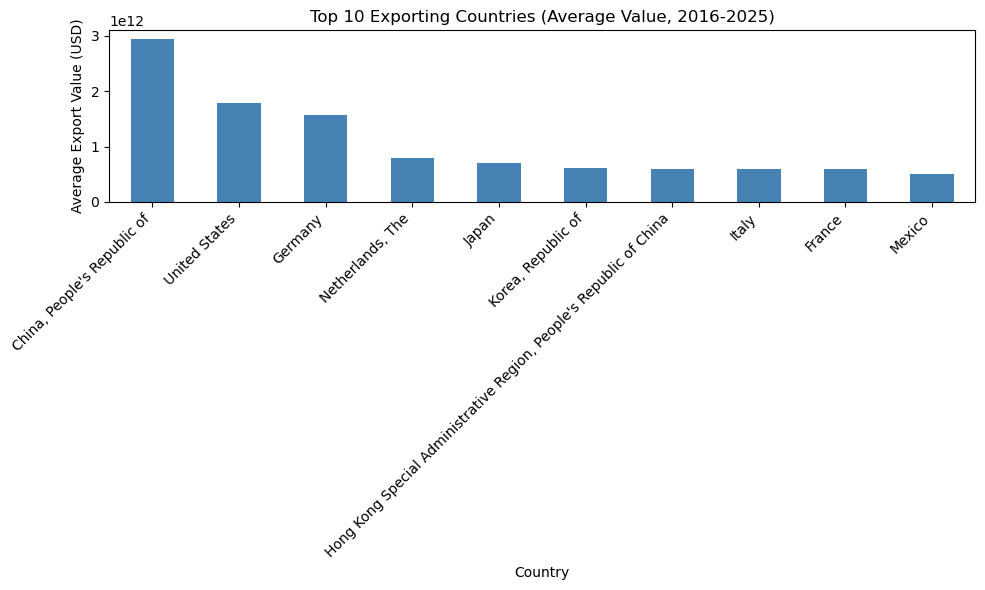

In [84]:
top_exporters = value_data[value_data['IS_EXPORT']].groupby('COUNTRY')['VALUE'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_exporters.plot(kind='bar', color='steelblue')
plt.title('Top 10 Exporting Countries (Average Value, 2016-2025)')
plt.xlabel('Country')
plt.ylabel('Average Export Value (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**4.2 Bar Chart — Top 10 Importing Countries**

What it does: Filters import data, calculates each country’s average import value (2016–2025), selects the Top 10, and displays them as a ranked bar chart.

Insight: The United States leads global imports by a clear margin, followed by China and major European economies — confirming the US as the world’s largest consumer market.

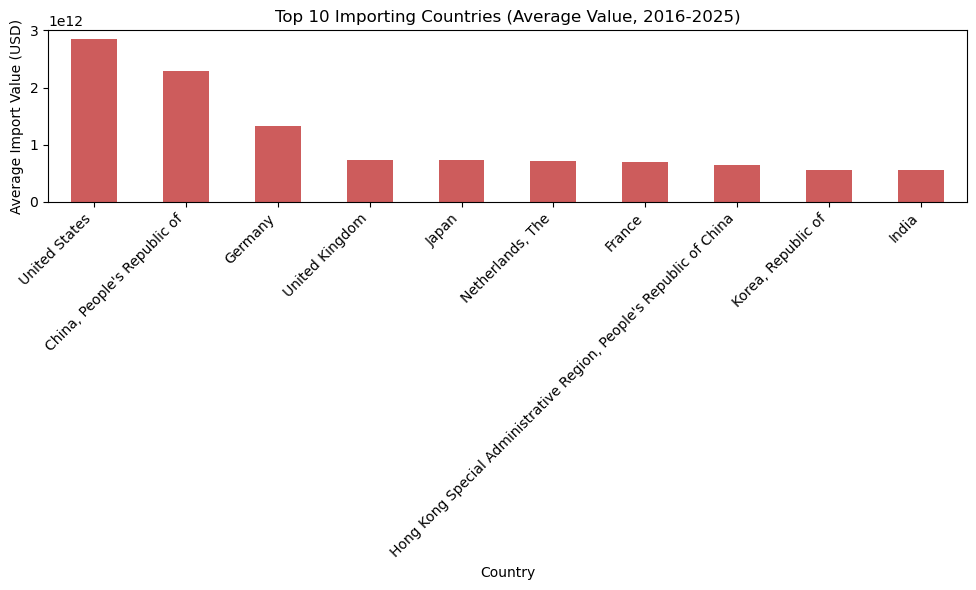

In [85]:
top_importers = value_data[~value_data['IS_EXPORT']].groupby('COUNTRY')['VALUE'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_importers.plot(kind='bar', color='indianred')
plt.title('Top 10 Importing Countries (Average Value, 2016-2025)')
plt.xlabel('Country')
plt.ylabel('Average Import Value (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**4.3 Line Chart — World Trade Over Time**

What it does: Groups trade data by year and trade flow (Exports/Imports), sums the values, and plots them as a line chart showing total world trade over time.

Insight: Both global exports and imports show a clear upward trend from 2016 to 2025, with a temporary dip around 2020 (COVID impact), followed by strong recovery — reflecting overall growth in world trade.

<Figure size 1000x600 with 0 Axes>

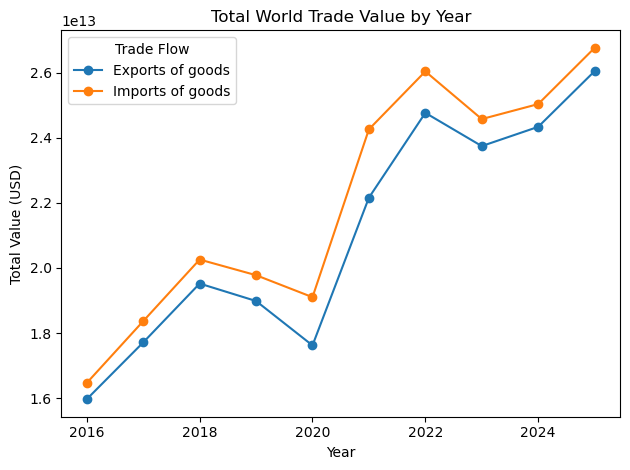

In [86]:
yearly_totals = value_data.groupby(['YEAR','TRADE_FLOW'])['VALUE'].sum().unstack()

plt.figure(figsize=(10,6))
yearly_totals.plot(kind='line', marker='o')
plt.title('Total World Trade Value by Year')
plt.xlabel('Year')
plt.ylabel('Total Value (USD)')
plt.legend(title='Trade Flow')
plt.tight_layout()
plt.show()

**4.4 Pie Chart — Trend Distribution**

What it does: Counts the number of “Increasing” and “Decreasing” trends (ignoring “No Data”) and displays their share as a pie chart.

Insight: A larger share of trade values show an increasing trend, indicating that most countries experienced growth in their trade values over the years rather than decline.

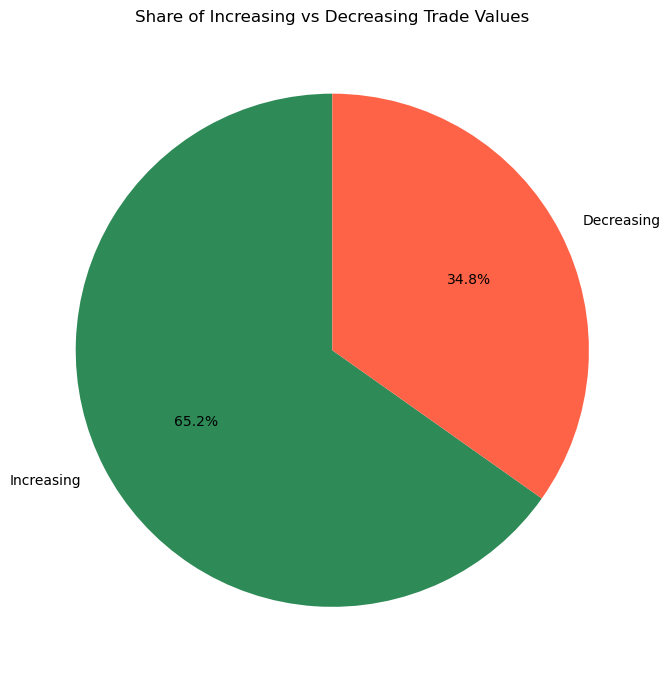

In [87]:
trend_counts = final[final['TREND'] != 'No Data']['TREND'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(trend_counts, labels=trend_counts.index, autopct='%1.1f%%',
        colors=['seagreen','tomato'], startangle=90)
plt.title('Share of Increasing vs Decreasing Trade Values')
plt.tight_layout()
plt.show()

**4.5 Histogram — Distribution of Index Scores**

What it does:
Creates a histogram of all index values (price and volume indices) using 30 bins. This shows how the index scores are distributed across the entire dataset.

Insight:
Most index values are concentrated around 100 (the base year), forming a clear peak. There is a moderate spread on both sides, meaning while many indices stayed close to the base year, a noticeable number of records show either increases (above 100) or decreases (below 100) over time.

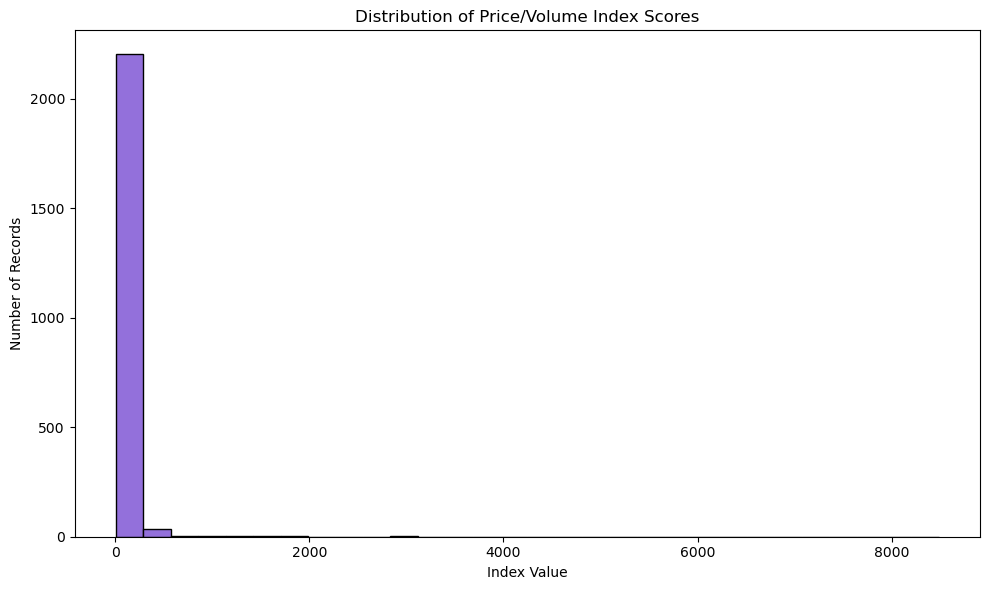

In [88]:
plt.figure(figsize=(10,6))
plt.hist(index_data['VALUE'], bins=30, color='mediumpurple', edgecolor='black')
plt.title('Distribution of Price/Volume Index Scores')
plt.xlabel('Index Value')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

**4.6 Box Plot — Exports vs Imports Spread**

What it does:
Creates a boxplot comparing the distribution (spread) of export and import values, using a log scale on the y-axis for better visibility of large differences.

Insight:
Imports and exports show similar overall ranges, but imports tend to have slightly higher median and upper values — reflecting that major importing countries often record larger absolute trade volumes than exporting ones.

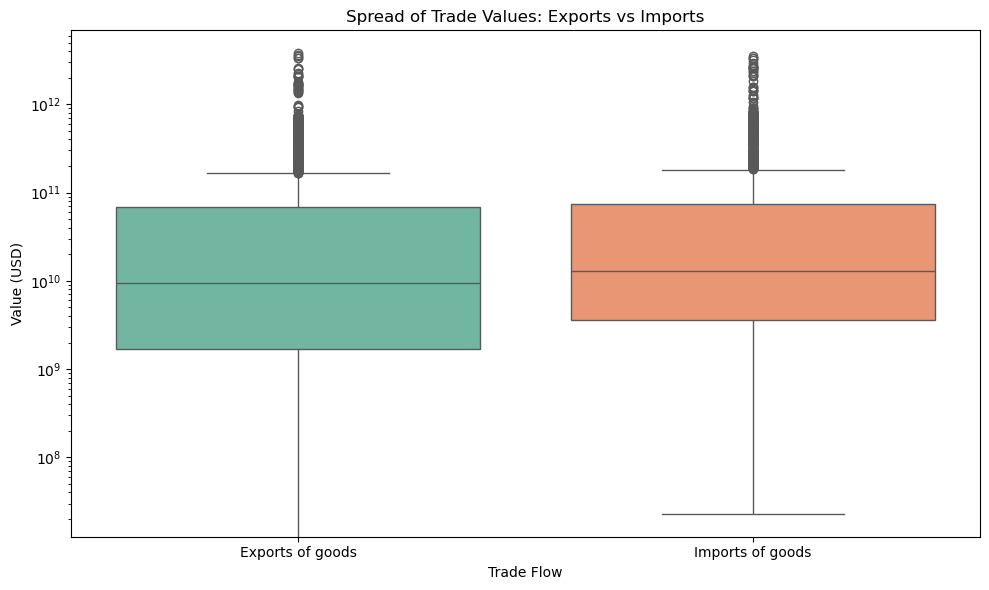

In [89]:
plt.figure(figsize=(10,6))
sns.boxplot(data=value_data, x='TRADE_FLOW', y='VALUE', hue='TRADE_FLOW', palette='Set2', legend=False)
plt.title('Spread of Trade Values: Exports vs Imports')
plt.xlabel('Trade Flow')
plt.ylabel('Value (USD)')
plt.yscale('log')
plt.tight_layout()
plt.show()

**4.7 Scatter Plot — Exports vs Imports (United States)**

What it does:
Creates a scatter plot of US Exports vs Imports for each year, showing the relationship between the two over time.

Insight:
US exports and imports move closely together, forming a clear upward pattern — confirming a strong positive relationship between the two, where higher exports tend to coincide with higher imports.

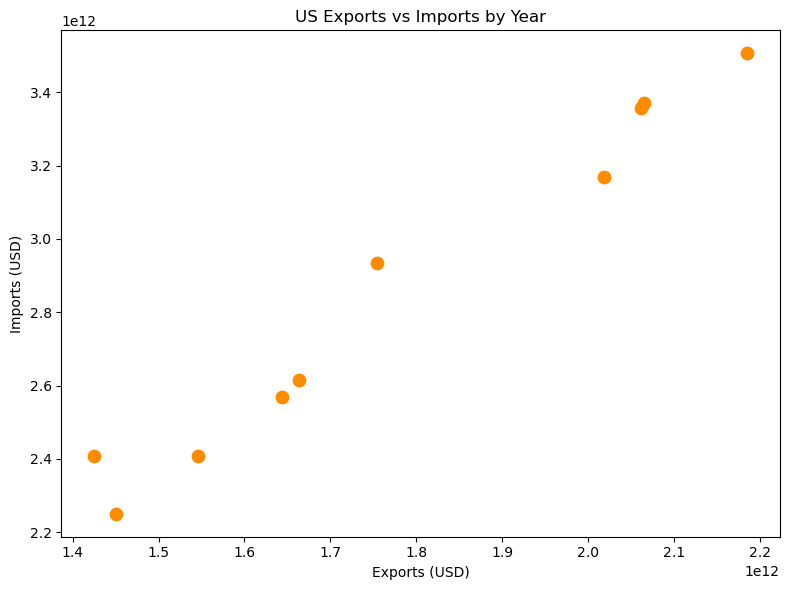

In [90]:
us_pivot = value_data[value_data['COUNTRY']=='United States'].pivot_table(
    index='YEAR', columns='TRADE_FLOW', values='VALUE'
)

plt.figure(figsize=(8,6))
plt.scatter(us_pivot['Exports of goods'], us_pivot['Imports of goods'], color='darkorange', s=80)
plt.title('US Exports vs Imports by Year')
plt.xlabel('Exports (USD)')
plt.ylabel('Imports (USD)')
plt.tight_layout()
plt.show()

**4.8 Heatmap — Top 10 Countries' Trade Over Time**

What it does:
Creates a heatmap of average trade values for the Top 10 exporting countries across years, with color intensity representing higher values.

Insight:
China consistently shows the darkest colors across most years, confirming its sustained dominance in global trade, while other top countries display more gradual increases over time.

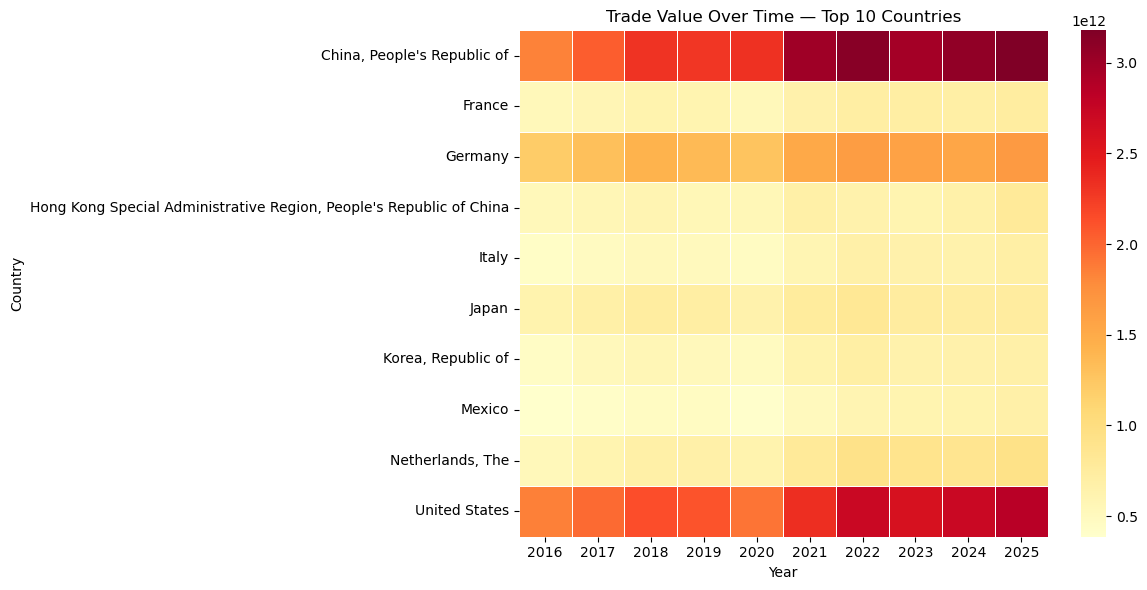

In [91]:
top10_names = top_exporters.index
heatmap_data = value_data[value_data['COUNTRY'].isin(top10_names)].pivot_table(
    index='COUNTRY', columns='YEAR', values='VALUE', aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5)
plt.title('Trade Value Over Time — Top 10 Countries')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**4.9 Subplots — Exports vs Imports Side by Side**

What it does:
Creates a side-by-side comparison of Top 10 Exporters and Top 10 Importers using two bar charts in one figure.

Insight:
China leads exports while the United States leads imports. Both countries appear high in each other’s lists, highlighting their deep mutual trade dependence and dominant positions in global trade.

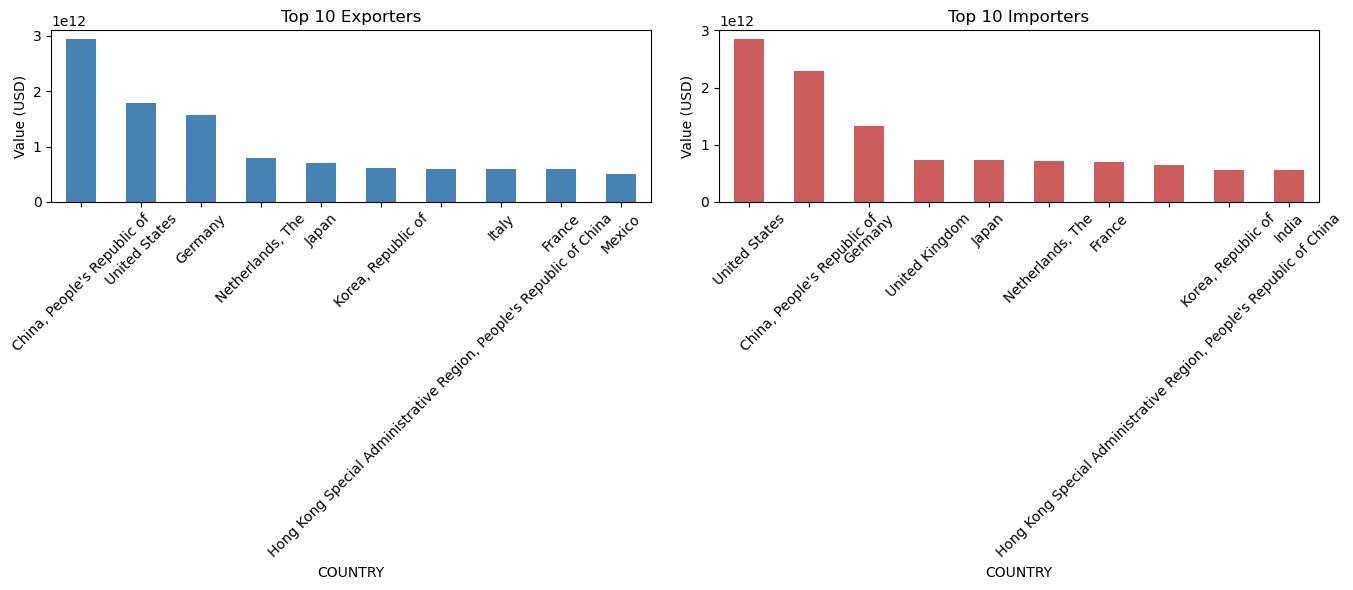

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

top_exporters.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Exporters')
axes[0].set_ylabel('Value (USD)')
axes[0].tick_params(axis='x', rotation=45)

top_importers.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Top 10 Importers')
axes[1].set_ylabel('Value (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**4.10 Bar Chart — Average Index Score by Indicator Type**

What it does:
Calculates the average value for each index type and displays them as a horizontal bar chart, sorted from lowest to highest.

Insight:
Most index types average close to or above 100, indicating overall growth compared to the base year, with some indicators (like volume indices) showing stronger increases than price-related ones.

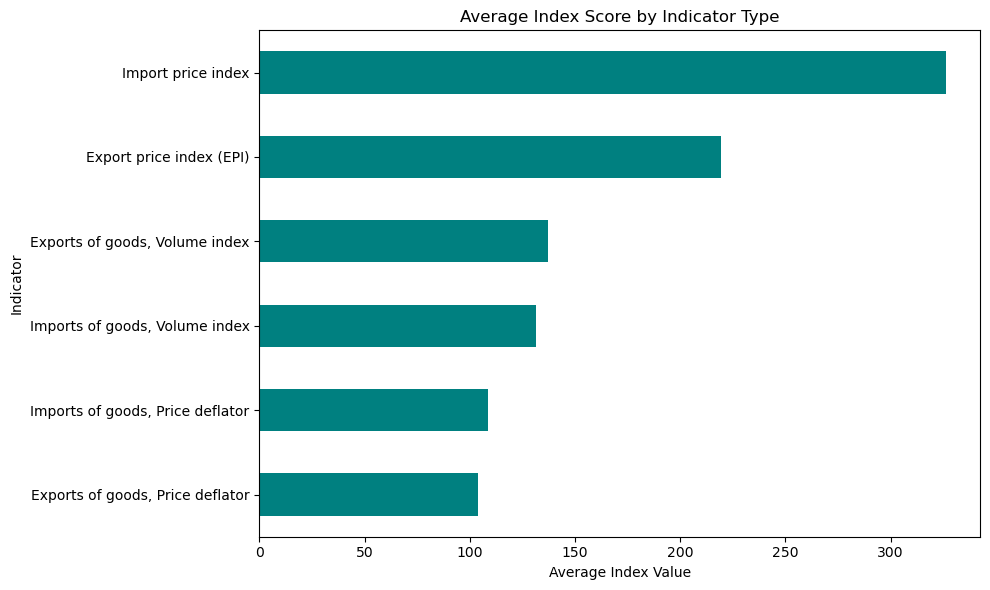

In [93]:
avg_by_indicator = index_data.groupby('INDICATOR')['VALUE'].mean().sort_values()

plt.figure(figsize=(10,6))
avg_by_indicator.plot(kind='barh', color='teal')
plt.title('Average Index Score by Indicator Type')
plt.xlabel('Average Index Value')
plt.ylabel('Indicator')
plt.tight_layout()
plt.show()

**5. Insight Generation and Report**

**Key Strategic Insights**

**1. Power Imbalance in Global Trade**

China leads global exports by a wide margin, while the United States leads imports.
This creates a clear structural imbalance: China acts as the primary supplier, and the US as the primary consumer.

Implication: Countries and companies that rely heavily on either market face concentrated risk (supply risk from China, demand risk from the US).

**2. Mutual Dependence is High but Asymmetric**

China and the US appear in each other’s Top 10 lists, confirming deep trade interdependence.
However, the nature of dependence differs: the US relies more on Chinese goods for consumption, while China relies on the US as a key export destination.

Implication: Trade tensions between these two economies can disrupt global supply chains significantly.

**3. Trade Growth is Resilient but Vulnerable to Shocks**

Global trade values show steady long-term growth (2016–2025), with a sharp but temporary decline in 2020.
The quick recovery after 2020 indicates strong underlying demand, but also highlights sensitivity to global crises.

Implication: Businesses should build flexible supply chains and maintain contingency plans for sudden disruptions.

**4. Most Countries Are Growing, but Concentration Risk Exists**

A majority of trade values show an Increasing trend.
However, a large share of total trade value is concentrated in a small number of countries (China, US, Germany, etc.).

Implication: Global trade growth is real, but highly dependent on a few major players. Diversification remains important.

**5. Exports and Imports Move Together**

In the case of the United States, exports and imports show a strong positive relationship.
This suggests that economic expansion tends to boost both export capacity and import demand simultaneously.This means improving the trade balance requires deeper structural changes (like reducing dependence on imported goods, improving domestic manufacturing, or changing consumption patterns), not just focusing on export growth alone.

Implication: Trade balance improvements are difficult to achieve solely through export growth; structural factors matter more.

**6. Index Behavior Reveals Underlying Price & Volume Dynamics**

Most price and volume indices cluster around the base year (100), with moderate upward and downward movements. (“Base year cluster” means the majority of index scores stay close to 100, showing that changes in prices and volumes have generally been moderate rather than extreme).
This indicates that while absolute trade values have grown significantly, real volume growth and price changes have been more moderate.

This tells us that the big rise in trade values is caused by two things together:

1. More goods being traded (volume growth)
2. Higher prices of those goods

Implication:

The growth in trade values is not only because countries are trading more goods.
A significant part of the increase also comes from rising prices.
So, when we see very high trade values, we should not assume it is pure volume growth — price increases are also playing an important role.


**Significant Patterns & Anomalies**

Global trade between 2016 and 2025 reveals a highly concentrated structure, where a small group of economies—particularly China as the dominant exporter and the United States as the leading importer—account for a disproportionately large share of total trade value. This concentration creates both efficiency and systemic risk: while these two economies drive global trade growth, any disruption between them can quickly transmit shocks across supply chains worldwide.
Despite this concentration, trade has shown notable resilience, recovering rapidly after the sharp 2020 decline. However, the same data also shows that exports and imports tend to rise and fall together, especially in major economies. This co-movement suggests that improvements in trade balances are difficult to achieve through export growth alone, as rising economic activity simultaneously fuels import demand.

Finally, while absolute trade values have increased substantially, price and volume indices remain relatively moderate and clustered around the base year. This indicates that the observed growth in trade values is driven by a combination of higher volumes and rising prices, rather than volume expansion alone—an important distinction for policymakers and businesses assessing real economic gains versus inflationary effects.

**Overall Conclusion**

Global trade from 2016 to 2025 shows strong growth but remains highly concentrated and deeply interdependent, especially between China and the United States. While the system recovered quickly from the 2020 shock, its reliance on a few dominant players makes it vulnerable. Rising trade values reflect both real volume growth and price increases, with benefits and risks unevenly distributed across countries.

**Recommendations for Informed Decision-Making**

**For Policymakers**

1. Reduce over-dependence on single trading partners by pursuing trade diversification strategies.
2. Closely monitor Terms of Trade and price indices to safeguard national purchasing power.

**For Businesses & Exporters**

1. Diversify export markets beyond China and the United States to lower concentration risk.
2. Build stronger supply chain resilience against geopolitical tensions and pandemic-type disruptions.

**For Analysts & Researchers**

1. Conduct deeper bilateral analysis, particularly focusing on China–US trade relations.
2. Clearly separate volume growth from price effects in future studies.
3. Develop early-warning indicators using trade indices to detect potential shocks.